In [1]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.table as at
import sncosmo
import pickle
import numpy as np
from astropy.table import Table

import sys
sys.path.insert(0, '/home/vk9342/GausSN')  # adjust if you cloned elsewhere

# Import the gausSN, kernel, meanfuncs, lensingmodels, and utils packages
import gaussn
from gaussn import gausSN, kernels, meanfuncs, lensingmodels, utils


In [2]:
print(os.path.dirname(gaussn.__file__))

/home/vk9342/GausSN/gaussn


In [3]:
## Load in scarlet2 fluxes

img_index = 62425 #62425 #1125   #72358   #17462  #96679
version = '_v7'
additional_path = 'different_separations/small_sep/'

if version == '_v6':
    folder = 'roman_both_epoch/'
elif version == '_v7':
    folder = 'roman_off_epoch/'
elif version == '_v8':
    folder = 'roman_no_epoch/'

oversamplefactor = 1

# scarlet_date = '29_03_26'  #used for saving images
scarlet_date = '14_04_26'  #used for saving images
save_path = f'{additional_path}{img_index}_results/{scarlet_date}/{folder}gaussn/'


# --- Load your Scarlet flux pickle file ---
with open('fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_'+str(img_index)+str(version)+'.pkl', 'rb') as f:
    flux_data = pickle.load(f)  # shape: [bands, epochs, images]

with open('fluxes_files/scarlet_deblended_flux_errors/rubin_scarlet_caustics_errors_'+str(img_index)+str(version)+'.pkl', 'rb') as f:
    variance_data = pickle.load(f)  # shape: [bands, epochs, images]

rubin_bands = ['lsstg', 'lsstr', 'lssti']



# sc_times = np.array([56150, 56154, 56158, 56162, 56166, 56170, 56180, 
#                      56190, 56200, 56210, 56210, 56220, 56230, 56240, 56250])  #96679
            
# sc_times = np.array([56150, 56160, 56170, 56180, 56188, 56190, 56200,
#                      56210, 56220, 56230, 56240, 56250, 56254, 56260, 56270])  #17462


# sc_times = np.array([0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130])
sc_times = np.array([0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140])

# Reformat to GaussSN style table
rows = []
for b_idx, band in enumerate(rubin_bands):                    # loop over bands (g, r, i)
    if b_idx != 0:
        for epoch_idx, (epoch_fluxes, epoch_variances) in enumerate(zip(flux_data[b_idx], variance_data[b_idx])): # loop over epochs
            for image_idx, (flux, variance) in enumerate(zip(epoch_fluxes, epoch_variances)):          # loop over image multiplicities
                rows.append({
                    'band': band,
                    'image': image_idx + 1, #2 - image_idx, #image_idx + 1,     #GausSN uses 1, 2, 3... (and not 0, 1, 2...) 
                    # 'image': 2 - image_idx, #2 - image_idx, #image_idx + 1, 
                    'time': sc_times[epoch_idx],
                    'flux': flux,
                    'fluxerr': variance   # ???? +/0.05 to avoid error = 0
                })


data = Table(rows)
data.sort(['band', 'image', 'time'])
# output_file = 'scarlet_fluxes_'+str(img_index)+version+'_gaussn_formatted.csv'
# data.write(output_file, format='csv', overwrite=True)


# Using your existing table (with fluxerr = sqrt(|flux|)*2 + 0.05)
median_errs = {}



for band in np.unique(data['band']):
    # mask for this band, and nonzero flux values
    mask = (data['band'] == band) & (data['flux'] != 0)
    
    # compute median only for those points
    if np.any(mask):
        # if band == 'lssti':
        #     median_errs[band] = np.median(data['fluxerr'][mask]) + 5
        # else:
        median_errs[band] = np.median(data['fluxerr'][mask])
    else:
        median_errs[band] = np.nan  # handle case if all fluxes are 0
    print(f"{band}: median fluxerr (excluding flux=0) = {median_errs[band]}")

# Replace all errors with that constant per band
for band in np.unique(data['band']):
    mask = data['band'] == band
    data['fluxerr'][mask] = median_errs[band]


print(data)  





An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


lssti: median fluxerr (excluding flux=0) = 0.11295548067837613
lsstr: median fluxerr (excluding flux=0) = 0.0990471324929495
 band image time    flux         fluxerr      
----- ----- ---- --------- -------------------
lssti     1    0       0.0 0.11295548067837613
lssti     1   10 0.7038252 0.11295548067837613
lssti     1   20 20.191607 0.11295548067837613
lssti     1   30 43.047604 0.11295548067837613
lssti     1   36  46.11228 0.11295548067837613
lssti     1   40  43.25767 0.11295548067837613
lssti     1   44 40.749924 0.11295548067837613
lssti     1   48 34.061527 0.11295548067837613
lssti     1   50  32.36598 0.11295548067837613
lssti     1   56  24.14611 0.11295548067837613
  ...   ...  ...       ...                 ...
lsstr     2   44 18.935835  0.0990471324929495
lsstr     2   48 16.196886  0.0990471324929495
lsstr     2   50  14.54578  0.0990471324929495
lsstr     2   56 13.528224  0.0990471324929495
lsstr     2   60 11.126653  0.0990471324929495
lsstr     2   70 6.2881737  0

In [4]:
for band in ['lsstr', 'lssti']: #rubin_bands:
    for img in [1, 2]:
        mask = (data['band'] == band) & (data['image'] == img)
        print(f"{band} image {img}: peak flux = {np.max(data['flux'][mask]):.2f}")

lsstr image 1: peak flux = 36.71
lsstr image 2: peak flux = 18.94
lssti image 1: peak flux = 46.11
lssti image 2: peak flux = 22.82


In [5]:
# data = data[data['band'] != 'lsstg']
# data = data[data['band'] != 'lssti']
# print(data)

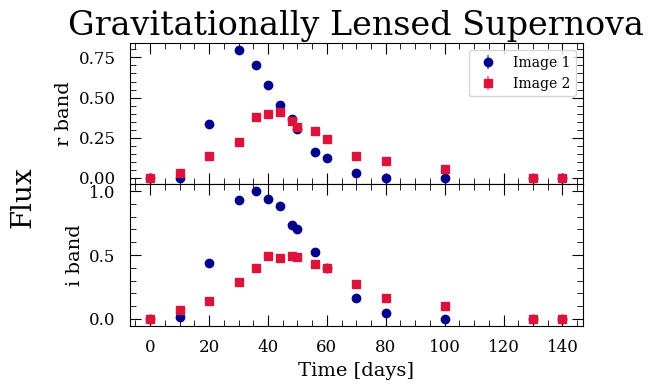

In [6]:
# NOrmalize fluxes
factor = np.max(data['flux']) - np.min(data['flux'])
data['flux'] = data['flux'] / factor
data['fluxerr'] = data['fluxerr'] / factor



# Normalize times so that the first epoch is 0
data['time'] = data['time'] - np.min(data['time'])

# Map LSST band names to what GaussSN expects
# band_map = {'g': 'lsstg', 'r': 'lsstr', 'i': 'lssti'}
# data['band'] = [band_map.get(b, b) for b in data['band']]

# Convert image index → string labels so utils.plot_object() doesn’t crash
data['image'] = [f"image_{i}" for i in data['image']]



fig, ax = utils.plot_object(data)

plt.show()




## Fitting with the GP model using a zero mean function
### Define a few functions that will be helpful for fitting/plotting

Note: for correct time delay estimation it may be helpful to make the brighter image the first one

In [7]:
# Specify a prior for dynesty's nested sampler
# See the dynesty documenation for more information about how to define a ptform
# def ptform(u):
#     prior = u
#     prior[0] = u[0]                 # A
#     prior[1] = (u[1] * 30) + 10     # tau
#     prior[2] = (u[2] * 40)          # delta_1,2
#     prior[3] = (u[3] * 0.9) + 0.1   # beta_1,2
#     return(prior)

# def ptform(u):
#     prior = u
#     prior[0] = (u[0] * 5)          # A
#     prior[1] = (u[1] * 48) + 2     # tau
#     prior[2] = (u[2] * 40)         # delta_1,2
#     prior[3] = (u[3] * 1.9) + 0.1  # beta_1,2
    # return(prior)


def ptform(u):
    prior = u.copy()
    prior[0] = (u[0] * 10)          # A: 0 to 5
    prior[1] = (u[1] * 50) + 5    # tau: 0.5 to 48.5
    prior[2] = (u[2] * 20) + 5    # delta: 5 to 20 days
    prior[3] = (u[3] * 3) + 0.1   # beta: 0.5 to 8.5 — wide enough for true ratio
    return prior
     

    
# Function for kernel and lensing parameter optimization
def fit_lensedSN(data, show_plots=False, save_plots=False):

    # Define a GP with a kernel and zero mean function
    meanfunc = meanfuncs.UniformMean([0])
    kernel = kernels.ExpSquaredKernel([0.5, 20])
    lensingmodel = lensingmodels.ConstantMagnification([0, 1])
    gp = gausSN.GP(kernel, meanfunc, lensingmodel)
        
    sampler = gp.optimize_parameters(x = data['time'], y = data['flux'], yerr = data['fluxerr'],
                                     band = data['band'], image = data['image'], fix_mean_params=True,
                                     method='dynesty', ptform=ptform, 
                                     # sampler_kwargs = {'sample': 'unif'}
                                     sampler_kwargs={
                                         'sample': 'rslice',      
                                         'bound': 'multi',       
                                         'bootstrap': 0,         
                                         'nlive': 500           
                                     }
                                    )

    
    # If desired, plot the results of the parameter optimization
    if show_plots:
        plt.figure()
        param_names = ['$A$', '$\\tau$', '$\\Delta$', '$\\beta$']  # amplitude , timescale, time delay, magnification 
        fig, ax = utils.make_corner(sampler.results, param_names)
        if save_plots:
            fig.savefig(f"{save_path}{img_index}_gaussn_fit1{version}_.png", bbox_inches='tight')
        fig.show()
            
        fig, ax = utils.make_traceplot(sampler.results, param_names)
        if save_plots:
            fig.savefig(f"{save_path}{img_index}_gaussn_fit2{version}_.png", bbox_inches='tight')
        fig.show()
            
    
    # Return the sampler, so you can save the chains or any other information about the optimization, if desired
    return sampler

11350it [04:27, 42.45it/s, +500 | bound: 58 | nc: 1 | ncall: 402041 | eff(%):  2.951 | loglstar:   -inf < -174.333 <    inf | logz: -196.329 +/-  0.209 | dlogz:  0.001 >  0.509]


<Figure size 640x480 with 0 Axes>

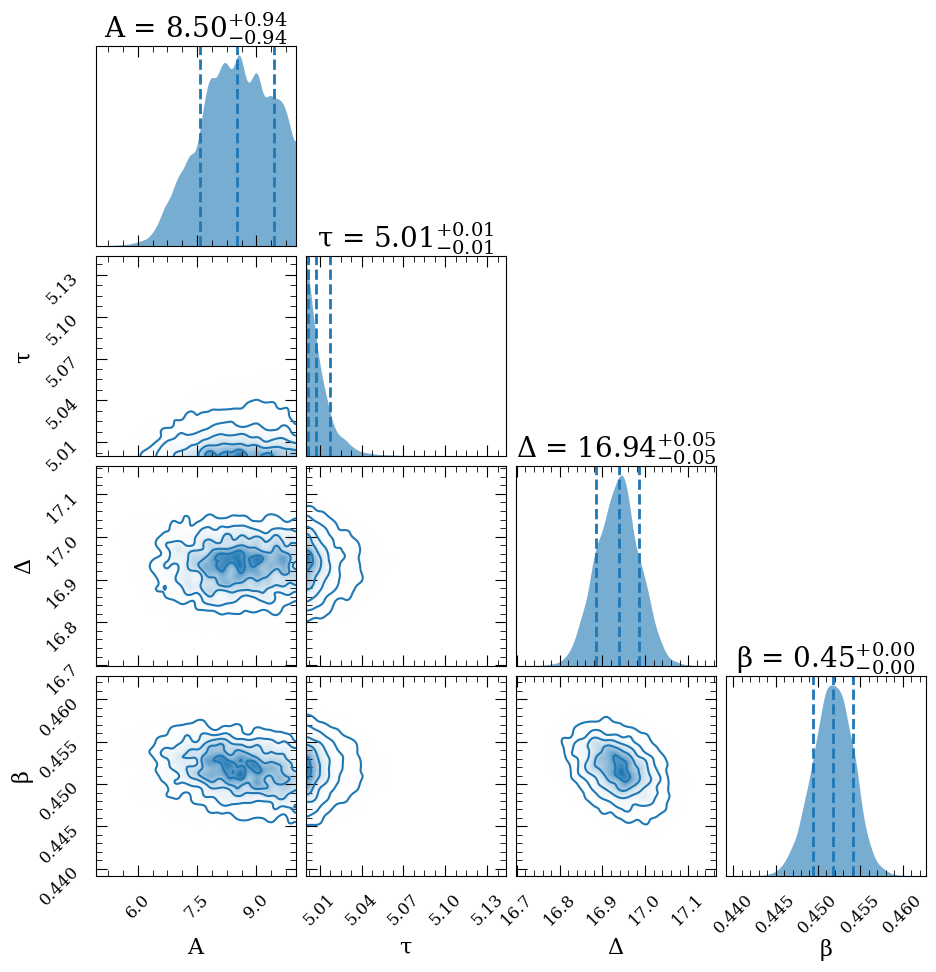

<Figure size 640x480 with 0 Axes>

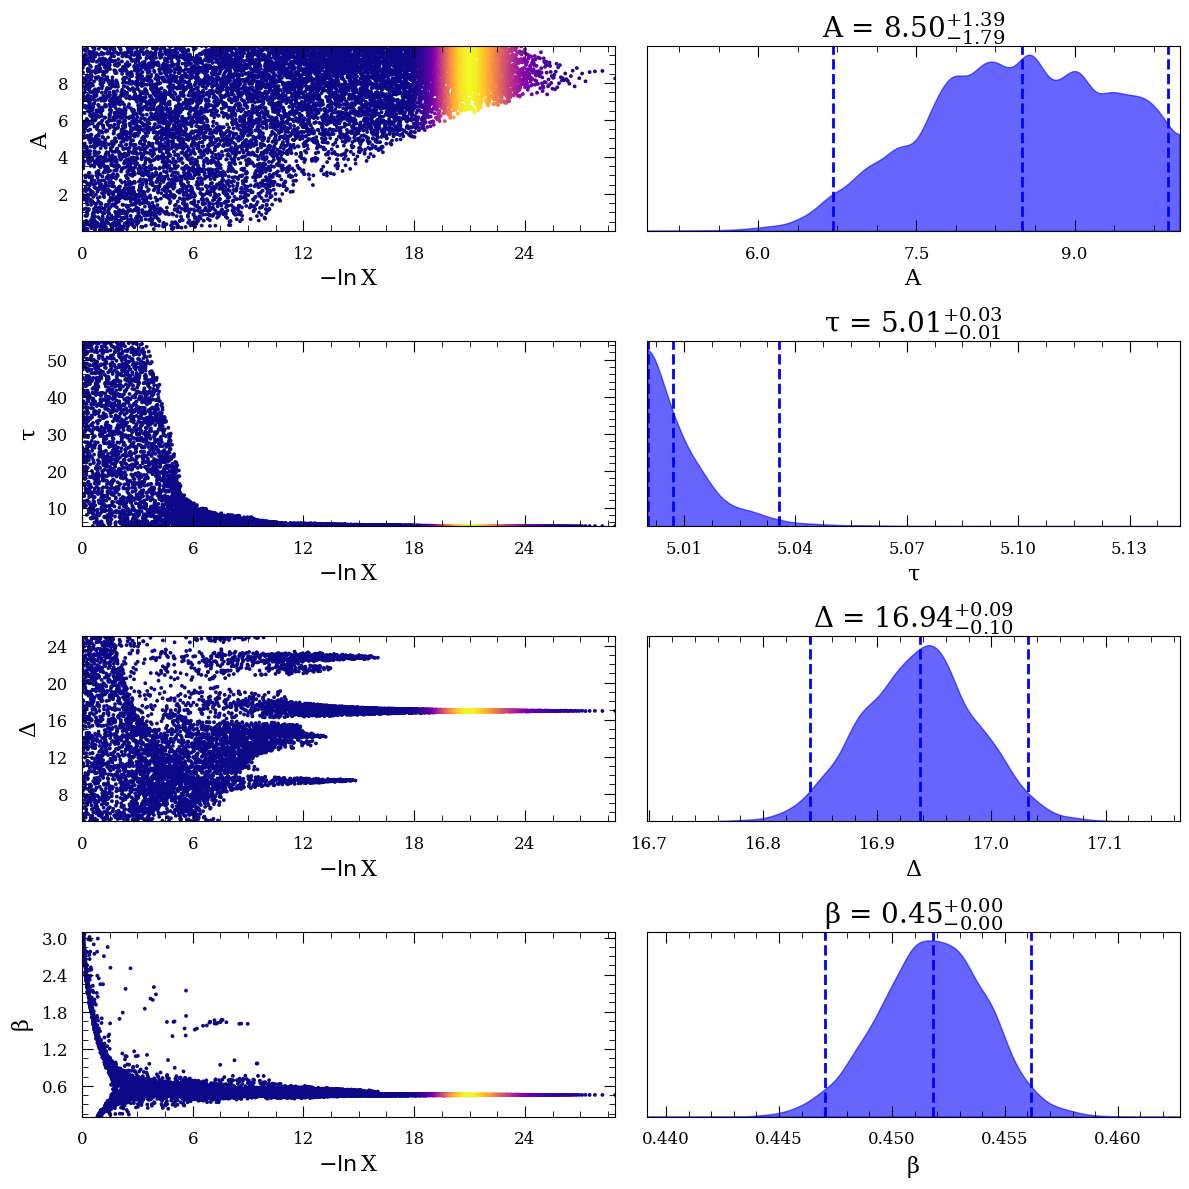

In [8]:
# Fit the light curve
sampler = fit_lensedSN(data, show_plots=True, save_plots= True)


### Plot the fitted light curve

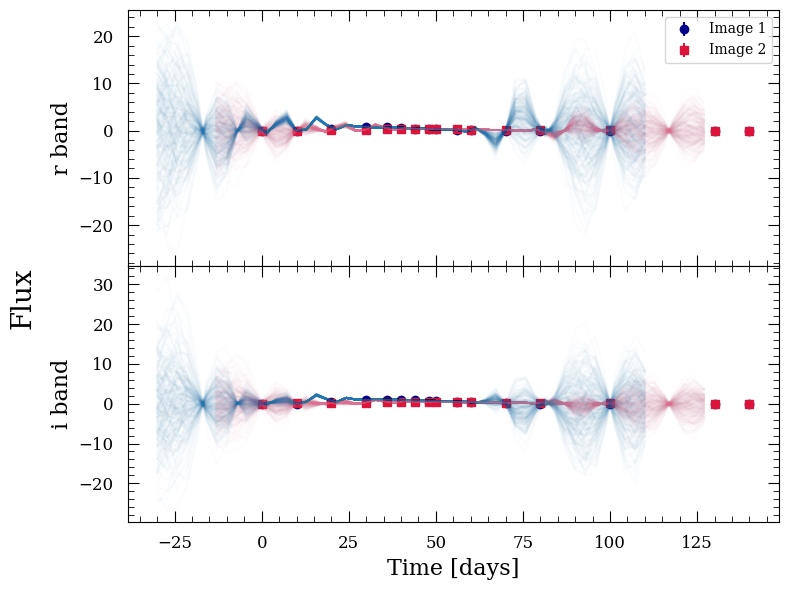

In [9]:
meanfunc = meanfuncs.UniformMean([0])
kernel = kernels.ExpSquaredKernel([0.5, 20])
lensingmodel = lensingmodels.ConstantMagnification([0, 1])

fig, ax = utils.plot_fitted_object(data, sampler.results, kernel, meanfunc, lensingmodel, fix_mean_params=True)
fig.savefig(f"{save_path}{img_index}_gaussn_fit_lc{version}_.png", bbox_inches='tight')


In [ ]:
tmin = float(np.min(data['time']))
tmax = float(np.max(data['time']))
fig, ax = utils.plot_fitted_object(
    data,
    sampler.results,
    kernels.ExpSquaredKernel([0.5, 20]),  
    meanfuncs.UniformMean([0.0]),
    lensingmodels.ConstantMagnification([0, 1]),
    fix_mean_params=True,
    predict_times=np.linspace(tmin, tmax, 200)  # <— clamp to data range
)

# Result from default GausSN setup

/home/vk9342/GausSN/gaussn/utils.py:221: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_vals = np.random.multivariate_normal(mean=exp, cov=cov, size=1)


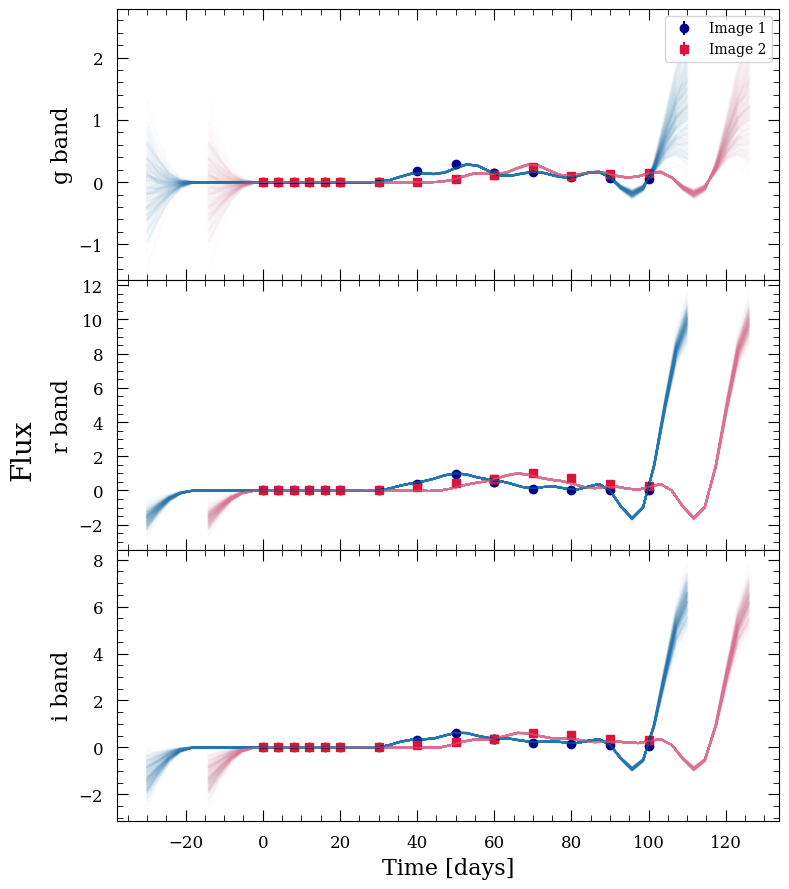

In [17]:
## OLD plot before modiifying code

meanfunc = meanfuncs.UniformMean([0])
kernel = kernels.ExpSquaredKernel([0.5, 20])
lensingmodel = lensingmodels.ConstantMagnification([0, 1])

fig, ax = utils.plot_fitted_object(data, sampler.results, kernel, meanfunc, lensingmodel, fix_mean_params=True)


# Run as loop

lsstg: median fluxerr (excluding flux=0) = 0.10755401901751419
lssti: median fluxerr (excluding flux=0) = 0.26124259271467765
lsstr: median fluxerr (excluding flux=0) = 0.24231385859088722
 band image time    flux         fluxerr      
----- ----- ---- --------- -------------------
lsstg     1    0       0.0 0.10755401901751419
lsstg     1   10 1.0563114 0.10755401901751419
lsstg     1   20 1.3822407 0.10755401901751419
lsstg     1   30 14.331768 0.10755401901751419
lsstg     1   36 29.758596 0.10755401901751419
lsstg     1   40  37.19214 0.10755401901751419
lsstg     1   44  34.76576 0.10755401901751419
lsstg     1   48 29.746994 0.10755401901751419
lsstg     1   50 26.856943 0.10755401901751419
lsstg     1   56 15.937601 0.10755401901751419
  ...   ...  ...       ...                 ...
lsstr     2   44 214.97401 0.24231385859088722
lsstr     2   48 181.38417 0.24231385859088722
lsstr     2   50  164.8955 0.24231385859088722
lsstr     2   56 119.46048 0.24231385859088722
lsstr     2 

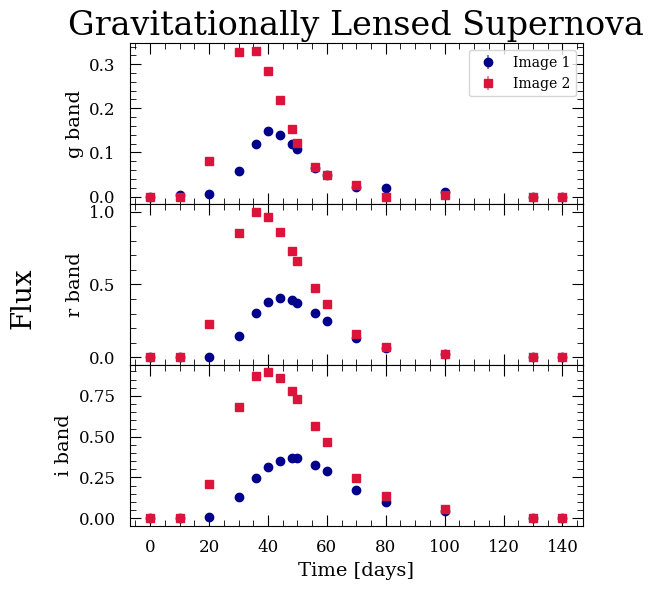

25062it [08:11, 51.04it/s, +500 | bound: 135 | nc: 1 | ncall: 931301 | eff(%):  2.746 | loglstar:   -inf < -835986.441 <    inf | logz: -836035.902 +/-  0.316 | dlogz:  0.001 >  0.509]


lsstg: median fluxerr (excluding flux=0) = 0.10252206746300346
lssti: median fluxerr (excluding flux=0) = 0.10010367674231371
lsstr: median fluxerr (excluding flux=0) = 0.11416729005827969
 band image time     flux           fluxerr      
----- ----- ---- ------------ -------------------
lsstg     1    0          0.0 0.10252206746300346
lsstg     1   10 6.079253e-06 0.10252206746300346
lsstg     1   20    24.612677 0.10252206746300346
lsstg     1   30     85.27699 0.10252206746300346
lsstg     1   36     85.73928 0.10252206746300346
lsstg     1   40    74.437004 0.10252206746300346
lsstg     1   44    58.352207 0.10252206746300346
lsstg     1   48    42.336018 0.10252206746300346
lsstg     1   50    34.441013 0.10252206746300346
lsstg     1   56     21.12409 0.10252206746300346
  ...   ...  ...          ...                 ...
lsstr     2   44    101.78548 0.11416729005827969
lsstr     2   48      98.8104 0.11416729005827969
lsstr     2   50     94.49867 0.11416729005827969
lsstr     2

<Figure size 640x480 with 0 Axes>

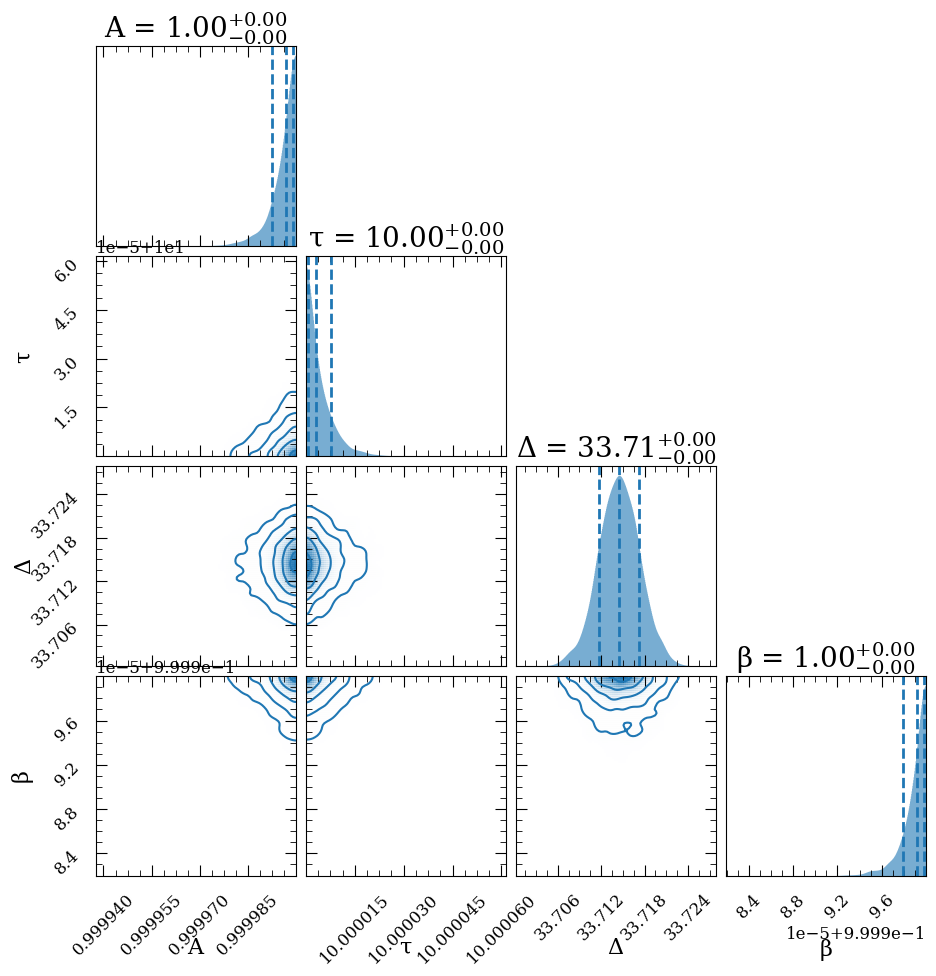

<Figure size 640x480 with 0 Axes>

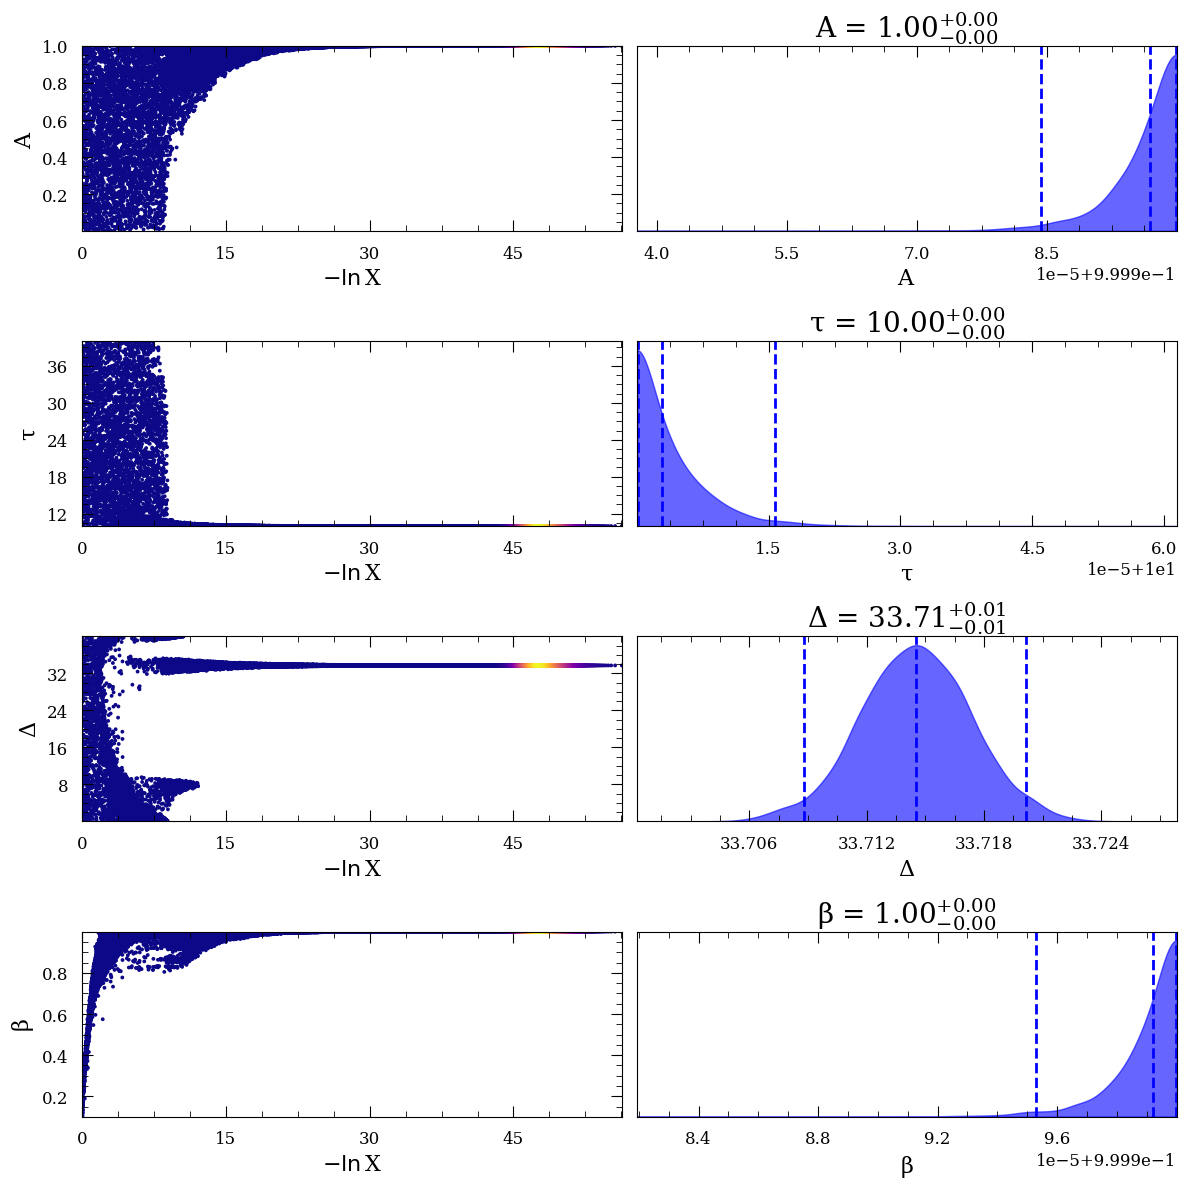

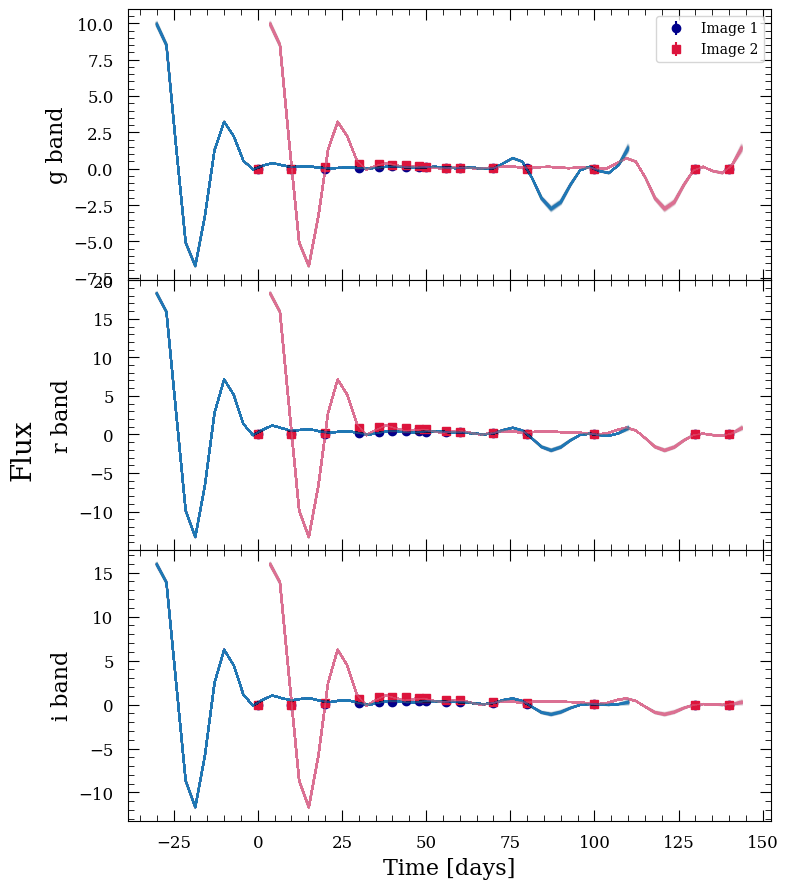

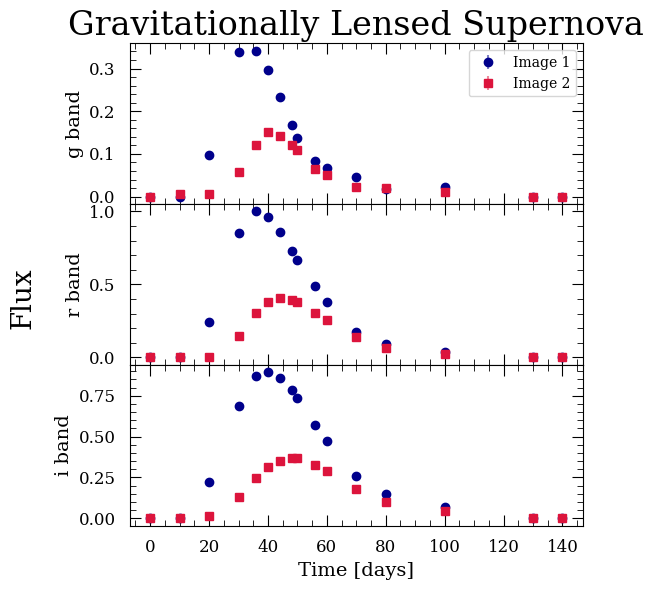

12838it [04:14, 50.39it/s, +500 | bound: 61 | nc: 1 | ncall: 434438 | eff(%):  3.074 | loglstar:   -inf < -488.720 <    inf | logz: -513.724 +/-  0.226 | dlogz:  0.001 >  0.509]  


lsstg: median fluxerr (excluding flux=0) = 0.8563793005601188
lssti: median fluxerr (excluding flux=0) = 0.9909114619036179
lsstr: median fluxerr (excluding flux=0) = 0.9309123653090334
 band image time    flux         fluxerr      
----- ----- ---- ---------- ------------------
lsstg     1    0        0.0 0.8563793005601188
lsstg     1   10 0.48775622 0.8563793005601188
lsstg     1   20  0.7368714 0.8563793005601188
lsstg     1   30 13.9605055 0.8563793005601188
lsstg     1   36  29.989538 0.8563793005601188
lsstg     1   40  37.732876 0.8563793005601188
lsstg     1   44  35.292126 0.8563793005601188
lsstg     1   48  30.070232 0.8563793005601188
lsstg     1   50  27.151434 0.8563793005601188
lsstg     1   56  15.697853 0.8563793005601188
  ...   ...  ...        ...                ...
lsstr     2   44  224.72263 0.9309123653090334
lsstr     2   48  190.53908 0.9309123653090334
lsstr     2   50  173.74513 0.9309123653090334
lsstr     2   56   127.5371 0.9309123653090334
lsstr     2   6

<Figure size 640x480 with 0 Axes>

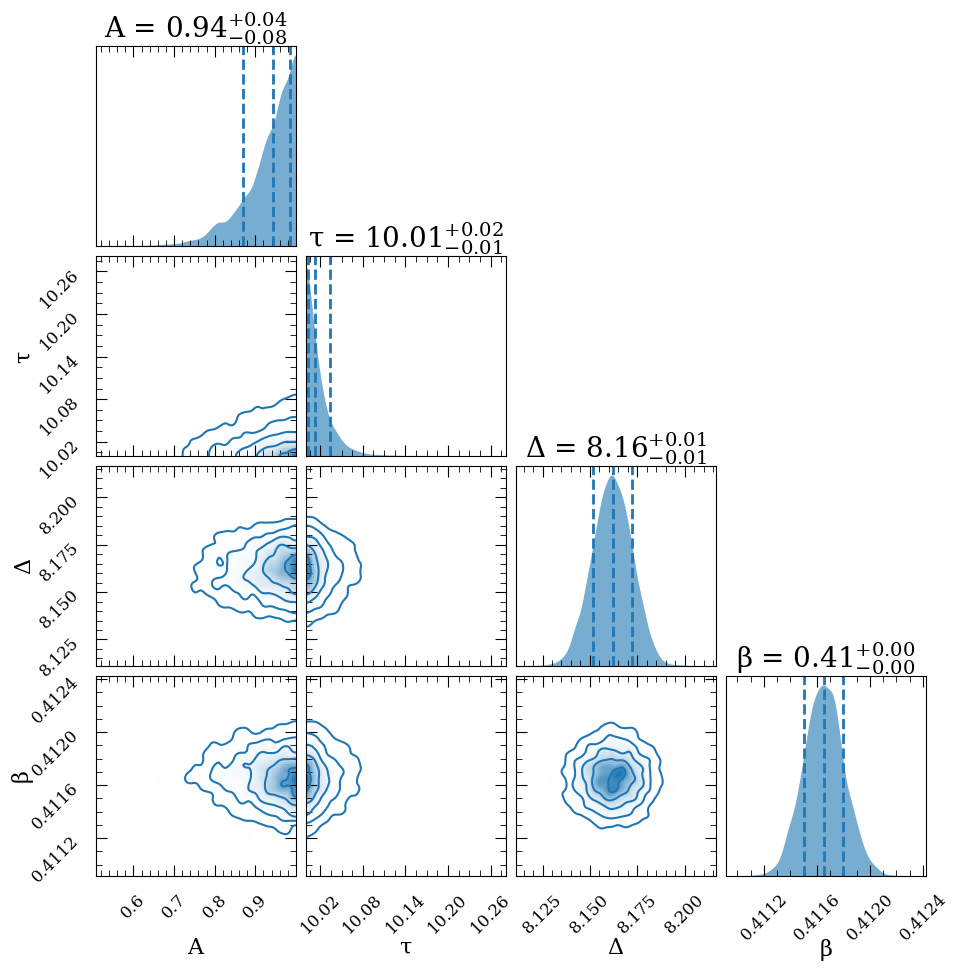

<Figure size 640x480 with 0 Axes>

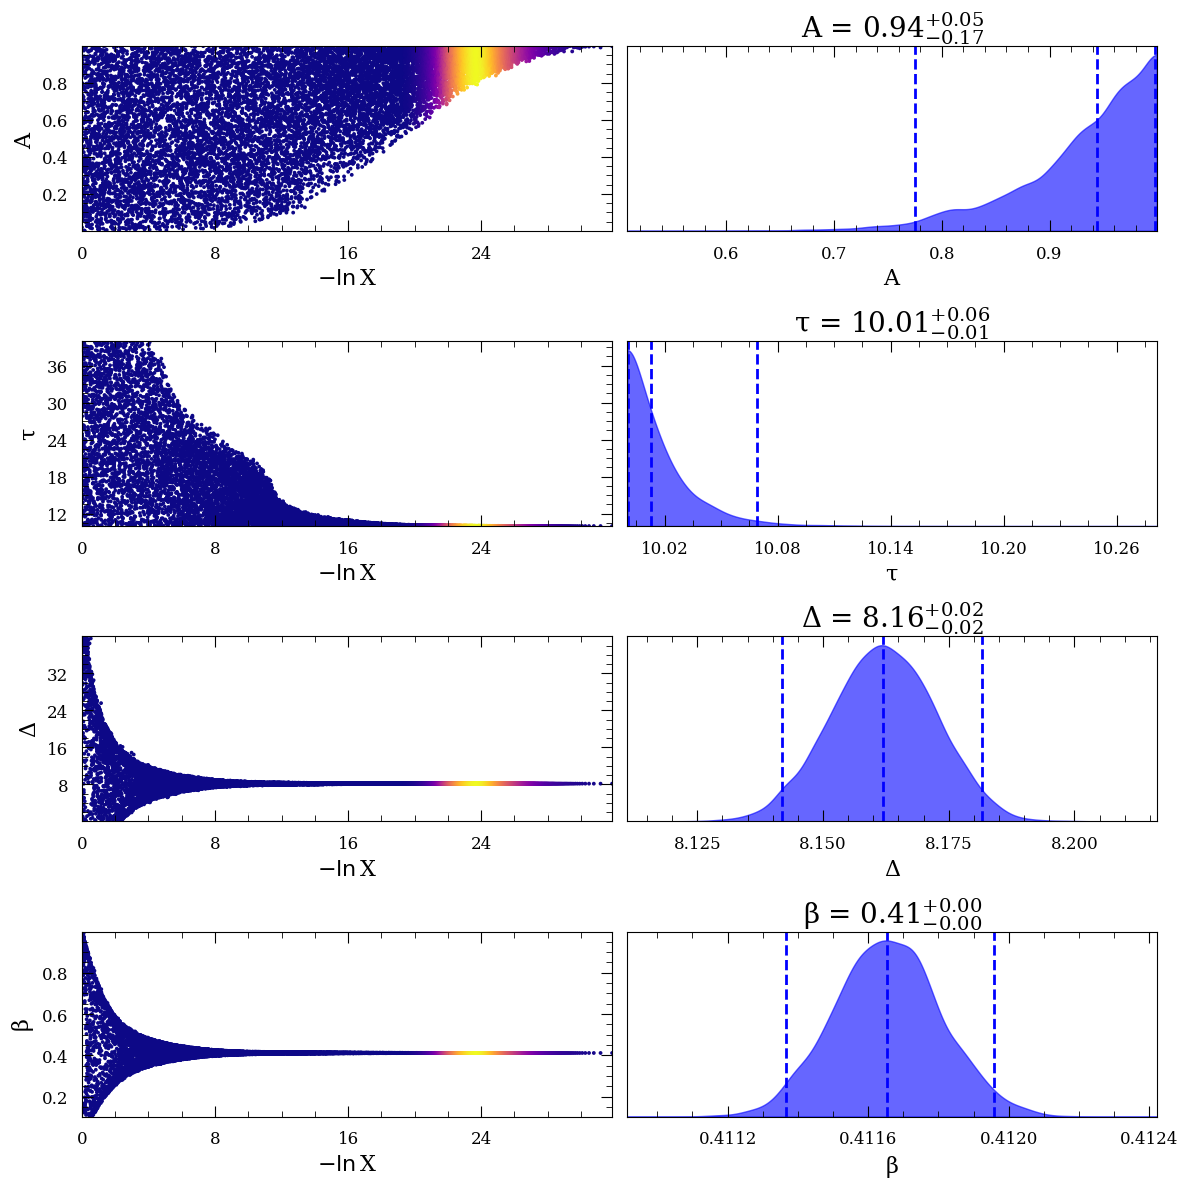

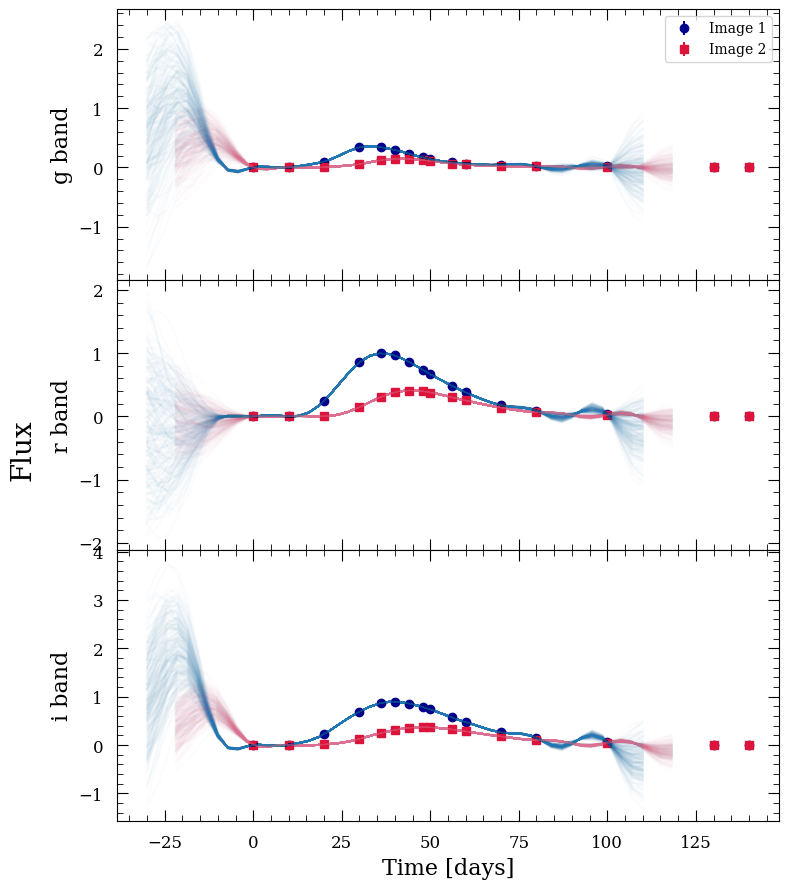

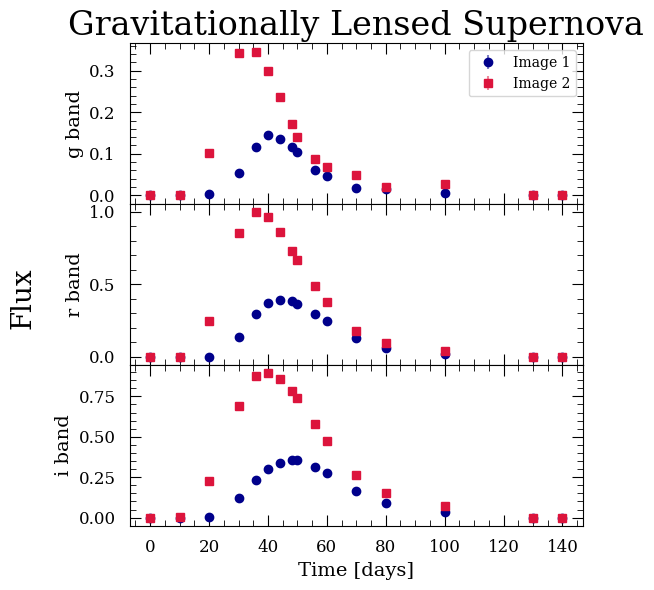

14110it [04:22, 53.71it/s, +500 | bound: 71 | nc: 1 | ncall: 490510 | eff(%):  2.982 | loglstar:   -inf < -73602.021 <    inf | logz: -73629.582 +/-  0.236 | dlogz:  0.001 >  0.509]


lsstg: median fluxerr (excluding flux=0) = 0.11409553222219354
lssti: median fluxerr (excluding flux=0) = 0.338482935507724
lsstr: median fluxerr (excluding flux=0) = 0.1846783627351275
 band image time    flux         fluxerr      
----- ----- ---- --------- -------------------
lsstg     1    0       0.0 0.11409553222219354
lsstg     1   10 1.3561597 0.11409553222219354
lsstg     1   20 4.1776223 0.11409553222219354
lsstg     1   30  13.26366 0.11409553222219354
lsstg     1   36 22.310682 0.11409553222219354
lsstg     1   40  22.43601 0.11409553222219354
lsstg     1   44 20.656244 0.11409553222219354
lsstg     1   48 16.254887 0.11409553222219354
lsstg     1   50 14.785788 0.11409553222219354
lsstg     1   56 10.291115 0.11409553222219354
  ...   ...  ...       ...                 ...
lsstr     2   44  87.91654  0.1846783627351275
lsstr     2   48 70.192116  0.1846783627351275
lsstr     2   50 62.135487  0.1846783627351275
lsstr     2   56 41.223804  0.1846783627351275
lsstr     2   6

<Figure size 640x480 with 0 Axes>

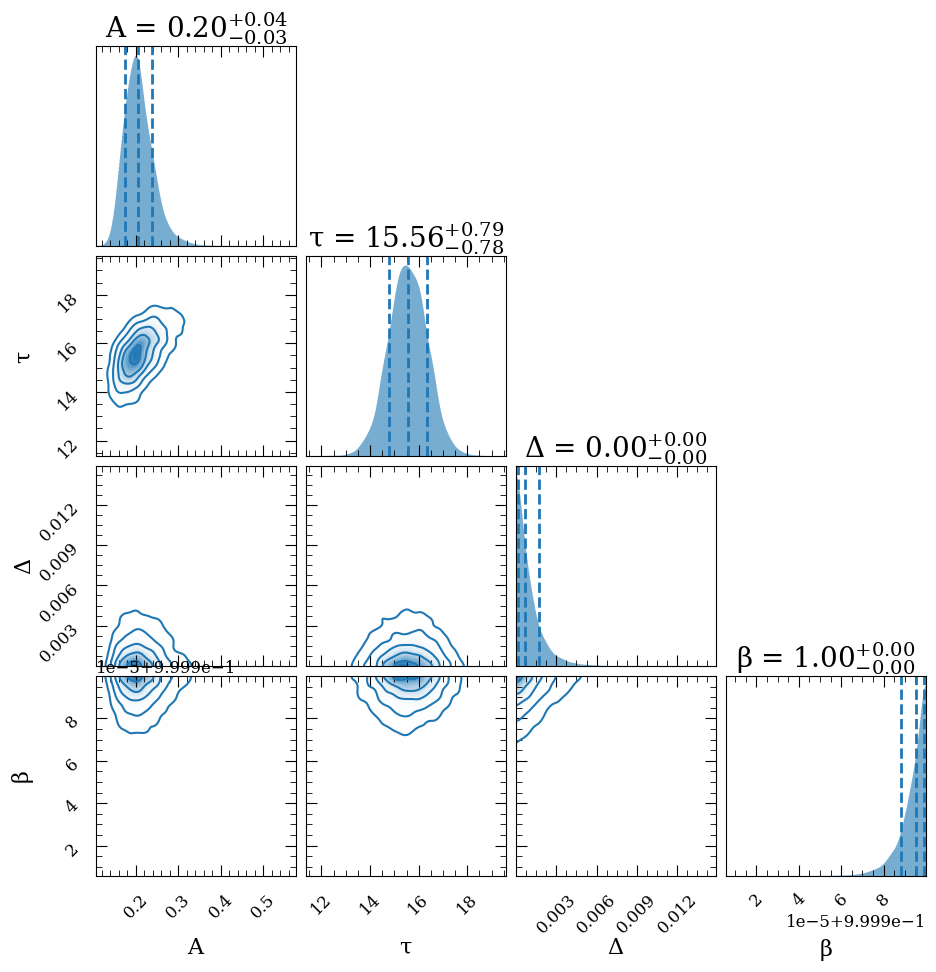

<Figure size 640x480 with 0 Axes>

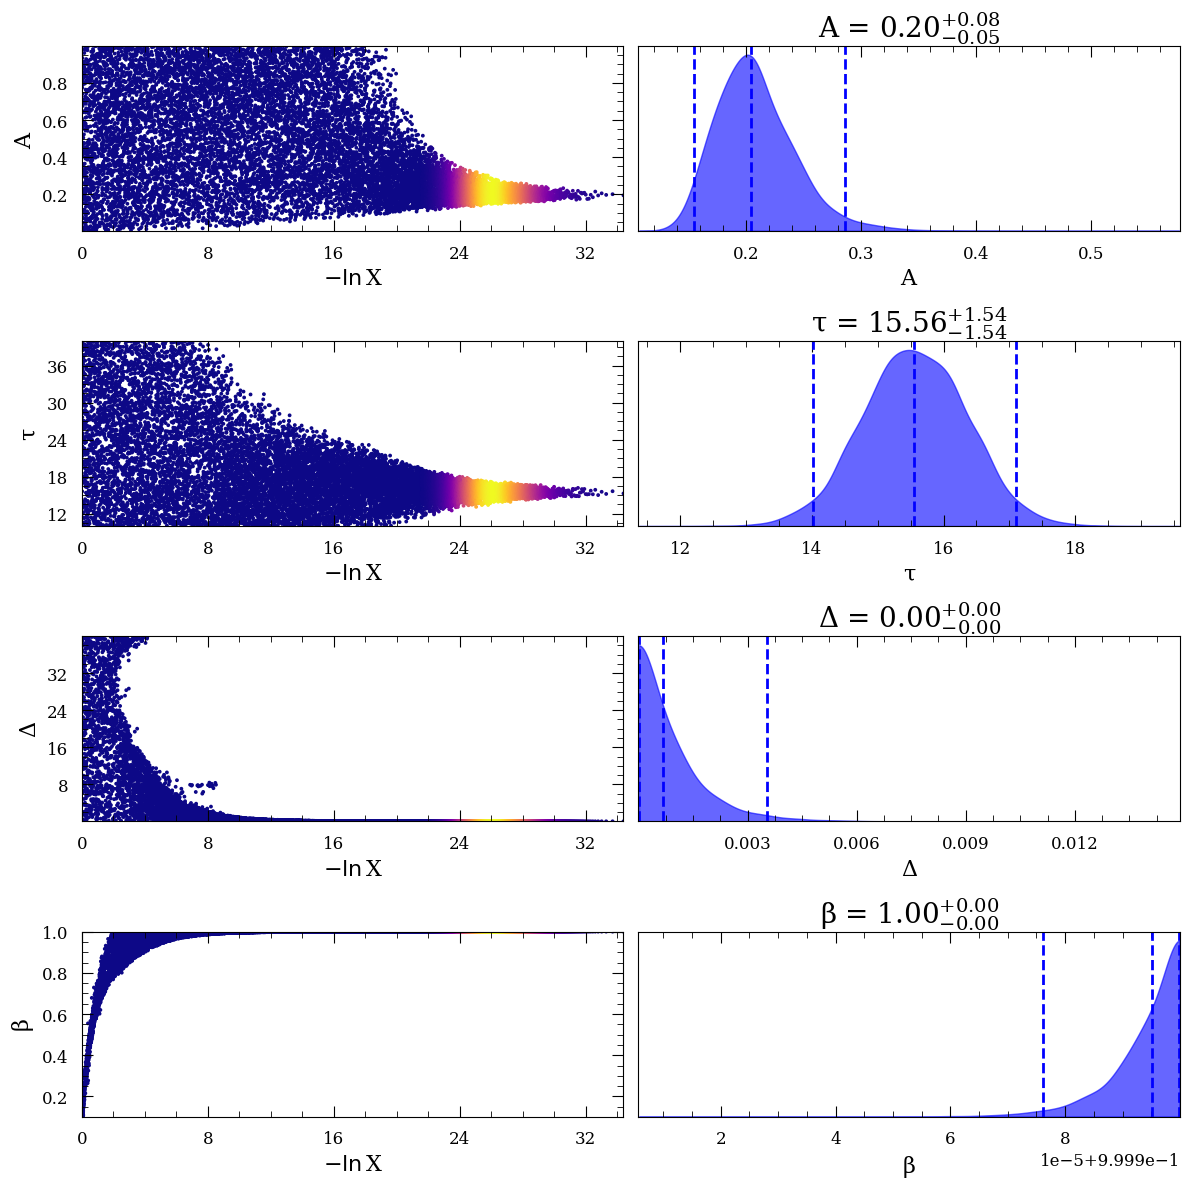

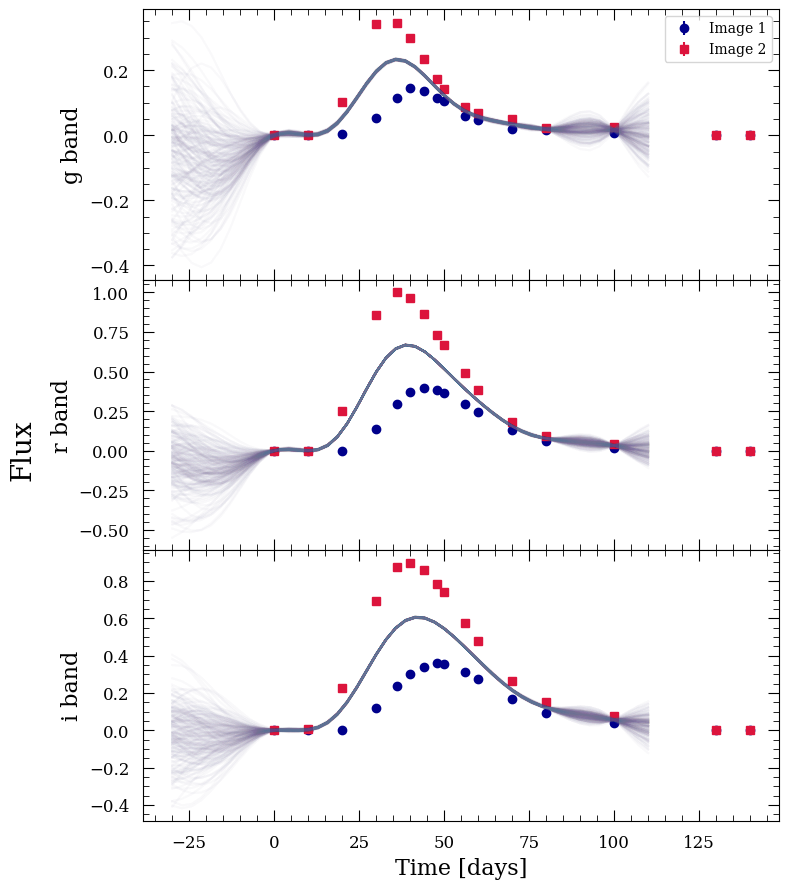

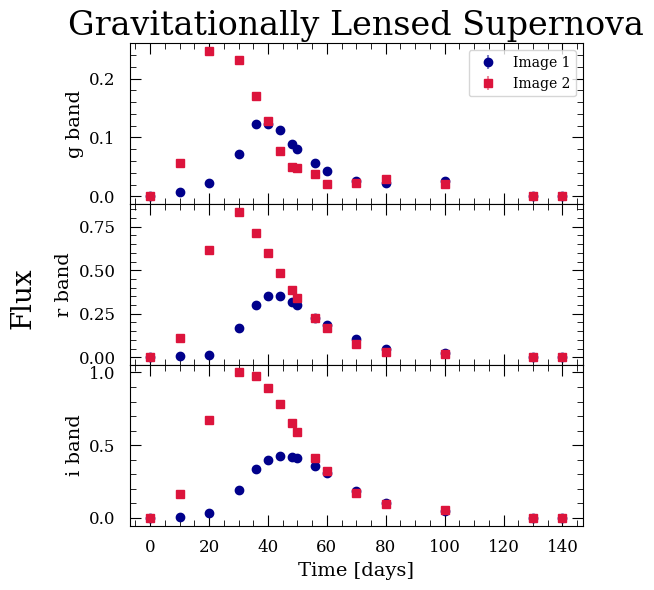

20662it [06:45, 54.27it/s, bound: 123 | nc: 36 | ncall: 791489 | eff(%):  2.611 | loglstar:   -inf < -281241.249 <    inf | logz: -281283.446 +/-  0.286 | dlogz: 12.967 >  0.509]   

In [ ]:
## Load in scarlet2 fluxes


img_indecies = [50421, 170330, 2737,
               157804, 64783, 111827,
               209546, 216276, 62425]


for img_index in img_indecies:
    for version in ['_v6', '_v7', '_v8']:
    # img_index = 157804 #62425 #1125   #72358   #17462  #96679
        # version = '_v6'
        if img_index == 50421 or img_index==  170330 or img_index == 2737:
            additional_path = 'different_separations/large_sep/'
        elif img_index == 157804 or img_index==  64783 or img_index == 111827:
            additional_path = 'different_separations/mid_sep/'
        elif img_index == 209546 or img_index== 216276 or img_index == 62425:
            additional_path = 'different_separations/small_sep/'
        
        if version == '_v6':
            folder = 'roman_both_epoch/'
        elif version == '_v7':
            folder = 'roman_off_epoch/'
        elif version == '_v8':
            folder = 'roman_no_epoch/'
        
        oversamplefactor = 1
        
        # scarlet_date = '29_03_26'  #used for saving images
        scarlet_date = '14_04_26'  #used for saving images
        save_path = f'{additional_path}{img_index}_results/{scarlet_date}/{folder}gaussn/'
        
        
        # --- Load your Scarlet flux pickle file ---
        with open('fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_'+str(img_index)+str(version)+'.pkl', 'rb') as f:
            flux_data = pickle.load(f)  # shape: [bands, epochs, images]
        
        with open('fluxes_files/scarlet_deblended_flux_errors/rubin_scarlet_caustics_errors_'+str(img_index)+str(version)+'.pkl', 'rb') as f:
            variance_data = pickle.load(f)  # shape: [bands, epochs, images]
        
        rubin_bands = ['lsstg', 'lsstr', 'lssti']
        
        
        
        # sc_times = np.array([56150, 56154, 56158, 56162, 56166, 56170, 56180, 
        #                      56190, 56200, 56210, 56210, 56220, 56230, 56240, 56250])  #96679
                    
        # sc_times = np.array([56150, 56160, 56170, 56180, 56188, 56190, 56200,
        #                      56210, 56220, 56230, 56240, 56250, 56254, 56260, 56270])  #17462
        
        
        # sc_times = np.array([0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130])
        sc_times = np.array([0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140])
        
        # Reformat to GaussSN style table
        rows = []
        for b_idx, band in enumerate(rubin_bands):                    # loop over bands (g, r, i)
            # if b_idx != 0:
            for epoch_idx, (epoch_fluxes, epoch_variances) in enumerate(zip(flux_data[b_idx], variance_data[b_idx])): # loop over epochs
                for image_idx, (flux, variance) in enumerate(zip(epoch_fluxes, epoch_variances)):          # loop over image multiplicities
                    rows.append({
                        'band': band,
                        'image': 2 - image_idx, #image_idx + 1,     #GausSN uses 1, 2, 3... (and not 0, 1, 2...) 
                        'time': sc_times[epoch_idx],
                        'flux': flux,
                        'fluxerr': variance   # ???? +/0.05 to avoid error = 0
                    })
        
        
        data = Table(rows)
        data.sort(['band', 'image', 'time'])
        # output_file = 'scarlet_fluxes_'+str(img_index)+version+'_gaussn_formatted.csv'
        # data.write(output_file, format='csv', overwrite=True)
        
        
        # Using your existing table (with fluxerr = sqrt(|flux|)*2 + 0.05)
        median_errs = {}
        
        
        
        for band in np.unique(data['band']):
            # mask for this band, and nonzero flux values
            mask = (data['band'] == band) & (data['flux'] != 0)
            
            # compute median only for those points
            if np.any(mask):
                # if band == 'lssti':
                #     median_errs[band] = np.median(data['fluxerr'][mask]) + 5
                # else:
                median_errs[band] = np.median(data['fluxerr'][mask])
            else:
                median_errs[band] = np.nan  # handle case if all fluxes are 0
            print(f"{band}: median fluxerr (excluding flux=0) = {median_errs[band]}")
        
        # Replace all errors with that constant per band
        for band in np.unique(data['band']):
            mask = data['band'] == band
            data['fluxerr'][mask] = median_errs[band]
        
        
        print(data)  
        
        
        # NOrmalize fluxes
        factor = np.max(data['flux']) - np.min(data['flux'])
        data['flux'] = data['flux'] / factor
        data['fluxerr'] = data['fluxerr'] / factor
        
        
        
        # Normalize times so that the first epoch is 0
        data['time'] = data['time'] - np.min(data['time'])
        
        # Map LSST band names to what GaussSN expects
        # band_map = {'g': 'lsstg', 'r': 'lsstr', 'i': 'lssti'}
        # data['band'] = [band_map.get(b, b) for b in data['band']]
        
        # Convert image index → string labels so utils.plot_object() doesn’t crash
        data['image'] = [f"image_{i}" for i in data['image']]
        
        
        
        fig, ax = utils.plot_object(data)
        
        plt.show()
        
        
        # Specify a prior for dynesty's nested sampler
        # See the dynesty documenation for more information about how to define a ptform
        def ptform(u):
            prior = u
            prior[0] = u[0]                 # A
            prior[1] = (u[1] * 30) + 10     # tau
            prior[2] = (u[2] * 40)          # delta_1,2
            prior[3] = (u[3] * 0.9) + 0.1   # beta_1,2
            return(prior)
        
        # def ptform(u):
        #     prior = u
        #     prior[0] = (u[0] * 5)          # A
        #     prior[1] = (u[1] * 48) + 2     # tau
        #     prior[2] = (u[2] * 40)         # delta_1,2
        #     prior[3] = (u[3] * 1.9) + 0.1  # beta_1,2
            # return(prior)
        
        
        # def ptform(u):
        #     prior = u.copy()
        #     prior[0] = (u[0] * 10)          # A: 0 to 5
        #     prior[1] = (u[1] * 50) + 0.5    # tau: 0.5 to 48.5
        #     prior[2] = (u[2] * 15) + 5    # delta: 5 to 20 days
        #     prior[3] = (u[3] * 2) + 0.1   # beta: 0.5 to 8.5 — wide enough for true ratio
        #     return prior
            
        
            
        # Function for kernel and lensing parameter optimization
        def fit_lensedSN(data, show_plots=False, save_plots=False):
        
            # Define a GP with a kernel and zero mean function
            meanfunc = meanfuncs.UniformMean([0])
            kernel = kernels.ExpSquaredKernel([0.5, 20])
            lensingmodel = lensingmodels.ConstantMagnification([0, 1])
            gp = gausSN.GP(kernel, meanfunc, lensingmodel)
                
            sampler = gp.optimize_parameters(x = data['time'], y = data['flux'], yerr = data['fluxerr'],
                                             band = data['band'], image = data['image'], fix_mean_params=True,
                                             method='dynesty', ptform=ptform, 
                                             # sampler_kwargs = {'sample': 'unif'}
                                             sampler_kwargs={
                                                 'sample': 'rslice',      
                                                 'bound': 'multi',       
                                                 'bootstrap': 0,         
                                                 'nlive': 500           
                                             }
                                            )
        
            
            # If desired, plot the results of the parameter optimization
            if show_plots:
                plt.figure()
                param_names = ['$A$', '$\\tau$', '$\\Delta$', '$\\beta$']  # amplitude , timescale, time delay, magnification 
                fig, ax = utils.make_corner(sampler.results, param_names)
                if save_plots:
                    fig.savefig(f"{save_path}{img_index}_gaussn_fit1{version}.png", bbox_inches='tight')
                fig.show()
                    
                fig, ax = utils.make_traceplot(sampler.results, param_names)
                if save_plots:
                    fig.savefig(f"{save_path}{img_index}_gaussn_fit2{version}.png", bbox_inches='tight')
                fig.show()
                    
            
            # Return the sampler, so you can save the chains or any other information about the optimization, if desired
            return sampler
        
        
        sampler = fit_lensedSN(data, show_plots=True, save_plots= True)
        
        
        meanfunc = meanfuncs.UniformMean([0])
        kernel = kernels.ExpSquaredKernel([0.5, 20])
        lensingmodel = lensingmodels.ConstantMagnification([0, 1])
        
        fig, ax = utils.plot_fitted_object(data, sampler.results, kernel, meanfunc, lensingmodel, fix_mean_params=True)
        fig.savefig(f"{save_path}{img_index}_gaussn_fit_lc{version}.png", bbox_inches='tight')
        
        
